In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from astropy.stats import sigma_clipped_stats

import hsc_downloader
from hsc_downloader import download_hsc_cutout

field_centers = [(150.106, 2.22092), (150.406, 2.52092)]

large_backgrounds = []
for ra, dec in field_centers:
    hdul_f = download_hsc_cutout(ra_center=ra, dec_center=dec, size_arcsec=400)
    large_backgrounds.append(hdul_f[1].data)

field_noise_stats = []
for field_bg in large_backgrounds:
    mean, median, std = sigma_clipped_stats(field_bg, sigma=3.0)
    field_noise_stats.append({'median': median, 'std': std})

print(field_noise_stats)

[{'median': np.float32(0.005664267), 'std': np.float32(0.013459231)}, {'median': np.float32(0.0063721426), 'std': np.float32(0.015171253)}]


In [2]:
metadata_with_heads = pd.read_parquet('../data/processed/injected_v1/injected_dataset_metadata_with_heads.parquet')

import head_labels
import importlib
importlib.reload(head_labels)
from lenstronomy.SimulationAPI.sim_api import SimAPI

def compute_snr_for_row(row, field_noise_stats, numPix=120, pixel_scale=0.168):
    if row['label'] == 0:
        return np.nan

    kwargs_lens = [{'theta_E': row['theta_E'], 'e1': row['e1_lens'], 'e2': row['e2_lens'],
                     'center_x': 0.0, 'center_y': 0.0}]
    kwargs_lens_light = [{'amp': row['amp_lens_light'], 'R_sersic': row['R_sersic_lens_light'],
                           'n_sersic': 4, 'e1': row['e1_lens'], 'e2': row['e2_lens'],
                           'center_x': 0.0, 'center_y': 0.0}]
    kwargs_source = [{'amp': 100, 'R_sersic': row['R_sersic_source'], 'n_sersic': row['n_sersic_source'],
                       'e1': row['e1_source'], 'e2': row['e2_source'],
                       'center_x': row['source_x'], 'center_y': row['source_y']}]

    kwargs_data = {
        'pixel_scale': pixel_scale, 'exposure_time': 100, 'magnitude_zero_point': 25.0,
        'sky_brightness': 30.0, 'read_noise': 0.001, 'ccd_gain': 2.5, 'psf_type': 'NONE'
    }
    sim_api = SimAPI(numpix=numPix, kwargs_single_band=kwargs_data, kwargs_model={
        'lens_model_list': ['SIE'], 'source_light_model_list': ['SERSIC_ELLIPSE'],
        'lens_light_model_list': ['SERSIC_ELLIPSE']
    })
    image_model = sim_api.image_model_class()

    full_signal = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source, kwargs_lens_light=kwargs_lens_light)
    galaxy_only = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=[{**kwargs_source[0], 'amp': 0}], kwargs_lens_light=kwargs_lens_light)
    isolated_arc = full_signal - galaxy_only

    total_signal_flux = np.sum(isolated_arc)
    n_significant_pixels = np.sum(isolated_arc > 0.01 * isolated_arc.max())

    field_std = field_noise_stats[int(row['field_idx'])]['std']
    snr = total_signal_flux / (field_std * np.sqrt(max(n_significant_pixels, 1)))

    return snr


from tqdm import tqdm

snr_values = []
for _, row in tqdm(metadata_with_heads.iterrows(), total=len(metadata_with_heads), desc="Computing SNR"):
    snr_values.append(compute_snr_for_row(row, field_noise_stats))

metadata_with_heads['snr'] = snr_values
print(metadata_with_heads[metadata_with_heads['label']==1]['snr'].describe())

Computing SNR: 100%|██████████| 3988/3988 [00:09<00:00, 442.35it/s] 

count     1993.000000
mean      2904.501269
std       2062.686073
min        358.338532
25%       1479.921563
50%       2404.204035
75%       3729.715394
max      18757.711922
Name: snr, dtype: float64


In [3]:
with h5py.File('../data/processed/injected_v1/injected_dataset.h5', 'r') as f:
    images = f['images'][:]

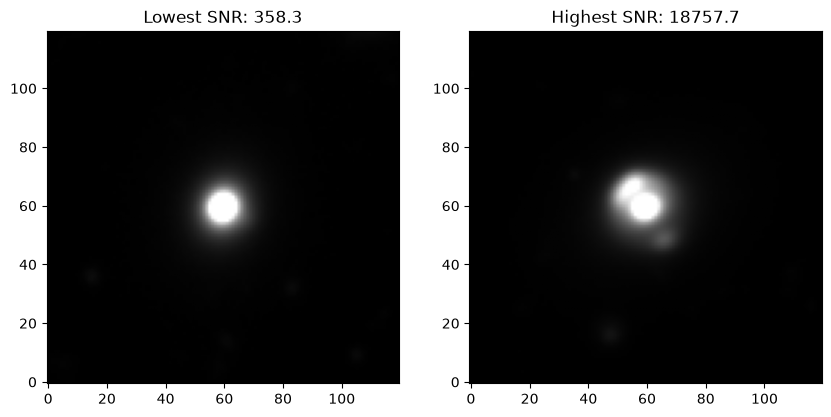

In [4]:
lens_only_meta = metadata_with_heads[metadata_with_heads['label'] == 1].reset_index(drop=True)
lens_only_images = images[metadata_with_heads['label'] == 1]

lowest_snr_idx = lens_only_meta['snr'].idxmin()
highest_snr_idx = lens_only_meta['snr'].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(lens_only_images[lowest_snr_idx], cmap='gray', origin='lower')
axes[0].set_title(f"Lowest SNR: {lens_only_meta['snr'].iloc[lowest_snr_idx]:.1f}")
axes[1].imshow(lens_only_images[highest_snr_idx], cmap='gray', origin='lower')
axes[1].set_title(f"Highest SNR: {lens_only_meta['snr'].iloc[highest_snr_idx]:.1f}")
plt.show()

In [5]:
lens_indices_sorted = metadata_with_heads[metadata_with_heads['label']==1].sort_values('snr', ascending=False).index.values
nonlens_indices = metadata_with_heads[metadata_with_heads['label']==0].index.values

n_stages = 4
stage_boundaries = np.linspace(0, len(lens_indices_sorted), n_stages + 1).astype(int)

print("Stage sizes (cumulative lens examples introduced):", stage_boundaries)

for i in range(n_stages):
    stage_snr_range = metadata_with_heads.loc[lens_indices_sorted[stage_boundaries[i]:stage_boundaries[i+1]], 'snr']
    print(f"Stage {i+1}: SNR range {stage_snr_range.min():.0f} - {stage_snr_range.max():.0f}, n={len(stage_snr_range)}")

Stage sizes (cumulative lens examples introduced): [   0  498  996 1494 1993]
Stage 1: SNR range 3734 - 18758, n=498
Stage 2: SNR range 2405 - 3730, n=498
Stage 3: SNR range 1480 - 2404, n=498
Stage 4: SNR range 358 - 1480, n=499


In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

labels_all = metadata_with_heads['label'].values
indices = np.arange(len(images))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels_all[temp_idx], random_state=42)

train_metadata = metadata_with_heads.iloc[train_idx].reset_index(drop=True)
train_images = images[train_idx]

print(len(train_idx), len(val_idx), len(test_idx))

train_lens_sorted = train_metadata[train_metadata['label']==1].sort_values('snr', ascending=False).index.values
train_nonlens_all = train_metadata[train_metadata['label']==0].index.values

stage_boundaries_train = np.linspace(0, len(train_lens_sorted), n_stages + 1).astype(int)
print("Train stage sizes:", stage_boundaries_train)

2791 598 599
Train stage sizes: [   0  348  697 1046 1395]


In [7]:
class CurriculumLensDataset(Dataset):
    def __init__(self, images, metadata_df):
        self.images = images
        self.labels = metadata_df['label'].values

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx]).float().unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


def build_stage_loader(stage_num, train_lens_sorted, train_nonlens_all, stage_boundaries_train,
                          train_images, train_metadata, batch_size=32):
    lens_subset_idx = train_lens_sorted[:stage_boundaries_train[stage_num]]

    n_nonlens_needed = len(lens_subset_idx)
    nonlens_subset_idx = np.random.choice(train_nonlens_all, size=min(n_nonlens_needed, len(train_nonlens_all)), replace=False)

    combined_idx = np.concatenate([lens_subset_idx, nonlens_subset_idx])
    np.random.shuffle(combined_idx)

    stage_dataset = CurriculumLensDataset(train_images[combined_idx], train_metadata.iloc[combined_idx])
    return DataLoader(stage_dataset, batch_size=batch_size, shuffle=True), len(combined_idx)

In [8]:
np.random.seed(42)
stage1_loader, stage1_size = build_stage_loader(1, train_lens_sorted, train_nonlens_all, stage_boundaries_train, train_images, train_metadata)
print("Stage 1 size:", stage1_size)

sample_batch = next(iter(stage1_loader))
print(sample_batch[0].shape, sample_batch[1].shape)
print("Label balance in batch:", sample_batch[1].float().mean().item())

Stage 1 size: 696
torch.Size([32, 1, 120, 120]) torch.Size([32])
Label balance in batch: 0.3125


In [9]:
import timm
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=True, in_chans=1, num_classes=0)

class LensClassifier(nn.Module):
    def __init__(self, encoder, feature_dim=640, num_classes=2):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        return self.classifier(self.encoder(x))

curriculum_model = LensClassifier(encoder).to(device)
optimizer = optim.Adam(curriculum_model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

val_dataset = CurriculumLensDataset(images[val_idx], metadata_with_heads.iloc[val_idx])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

def train_one_epoch_simple(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images_batch, labels_batch in loader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * images_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels_batch).sum().item()
        total += labels_batch.size(0)
    return total_loss / total, correct / total

def evaluate_simple(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images_batch, labels_batch in loader:
            images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)
            total_loss += loss.item() * images_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels_batch).sum().item()
            total += labels_batch.size(0)
    return total_loss / total, correct / total


epochs_per_stage = 4
best_val_loss = float('inf')
curriculum_history = []

for stage_num in range(1, n_stages + 1):
    stage_loader, stage_size = build_stage_loader(stage_num, train_lens_sorted, train_nonlens_all,
                                                     stage_boundaries_train, train_images, train_metadata)
    print(f"\n=== Stage {stage_num}/{n_stages} (size={stage_size}) ===")

    for epoch in range(epochs_per_stage):
        train_loss, train_acc = train_one_epoch_simple(curriculum_model, stage_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_simple(curriculum_model, val_loader, criterion, device)

        marker = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(curriculum_model.state_dict(), '../models/curriculum_convnext_nano_best.pt')
            marker = " [NEW BEST]"

        print(f"  Stage {stage_num}, Epoch {epoch+1}/{epochs_per_stage} - train_loss: {train_loss:.4f}, "
              f"train_acc: {train_acc:.4f}, val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}{marker}")

        curriculum_history.append({'stage': stage_num, 'epoch': epoch+1, 'train_loss': train_loss,
                                     'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc})


=== Stage 1/4 (size=696) ===
  Stage 1, Epoch 1/4 - train_loss: 0.5439, train_acc: 0.7543, val_loss: 0.4674, val_acc: 0.7709 [NEW BEST]
  Stage 1, Epoch 2/4 - train_loss: 0.1884, train_acc: 0.9368, val_loss: 0.2991, val_acc: 0.8813 [NEW BEST]
  Stage 1, Epoch 3/4 - train_loss: 0.0588, train_acc: 0.9828, val_loss: 0.3360, val_acc: 0.9013
  Stage 1, Epoch 4/4 - train_loss: 0.0273, train_acc: 0.9914, val_loss: 0.4121, val_acc: 0.9147

=== Stage 2/4 (size=1394) ===
  Stage 2, Epoch 1/4 - train_loss: 0.0451, train_acc: 0.9892, val_loss: 0.3502, val_acc: 0.9448
  Stage 2, Epoch 2/4 - train_loss: 0.0286, train_acc: 0.9914, val_loss: 0.2180, val_acc: 0.9498 [NEW BEST]
  Stage 2, Epoch 3/4 - train_loss: 0.0118, train_acc: 0.9971, val_loss: 0.3443, val_acc: 0.9565
  Stage 2, Epoch 4/4 - train_loss: 0.0024, train_acc: 0.9986, val_loss: 0.4042, val_acc: 0.9498

=== Stage 3/4 (size=2092) ===
  Stage 3, Epoch 1/4 - train_loss: 0.1133, train_acc: 0.9775, val_loss: 0.2103, val_acc: 0.9599 [NEW BEST]


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

eval_curriculum_model = LensClassifier(timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=False, in_chans=1, num_classes=0)).to(device)
eval_curriculum_model.load_state_dict(torch.load('../models/curriculum_convnext_nano_best.pt'))
eval_curriculum_model.eval()

test_dataset = CurriculumLensDataset(images[test_idx], metadata_with_heads.iloc[test_idx])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

all_preds_c = []
all_labels_c = []
with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs = eval_curriculum_model(images_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds_c.extend(predicted.cpu().numpy())
        all_labels_c.extend(labels_batch.numpy())

print(classification_report(all_labels_c, all_preds_c, target_names=['non-lens', 'lens']))
print(confusion_matrix(all_labels_c, all_preds_c))

              precision    recall  f1-score   support

    non-lens       0.97      1.00      0.98       300
        lens       1.00      0.97      0.98       299

    accuracy                           0.98       599
   macro avg       0.98      0.98      0.98       599
weighted avg       0.98      0.98      0.98       599

[[300   0]
 [ 10 289]]


In [11]:
import sys
sys.path.append('../src')
import timm
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MultiHeadLensModel(nn.Module):
    def __init__(self, encoder, feature_dim=640):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, 2)
        self.ring_head = nn.Linear(feature_dim, 1)
        self.asymmetry_head = nn.Linear(feature_dim, 1)
        self.colour_head = nn.Linear(feature_dim, 1)
        self.elongation_head = nn.Linear(feature_dim, 1)

    def forward(self, x):
        features = self.encoder(x)
        return {
            'class_logits': self.classifier(features),
            'ring': torch.sigmoid(self.ring_head(features)).squeeze(-1),
            'asymmetry': torch.nn.functional.softplus(self.asymmetry_head(features)).squeeze(-1),
            'colour': torch.nn.functional.softplus(self.colour_head(features)).squeeze(-1),
            'elongation': torch.sigmoid(self.elongation_head(features)).squeeze(-1),
        }

eval_model = MultiHeadLensModel(timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=False, in_chans=1, num_classes=0)).to(device)
eval_model.load_state_dict(torch.load('../models/multihead_convnext_nano_best.pt'))
eval_model.eval()

test_dataset_mh = CurriculumLensDataset(images[test_idx], metadata_with_heads.iloc[test_idx])
test_loader_mh = DataLoader(test_dataset_mh, batch_size=32, shuffle=False)

all_confidences = []
all_correct = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader_mh:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
        outputs = eval_model(images_batch)
        probs = torch.softmax(outputs['class_logits'], dim=1)
        confidences, predicted = torch.max(probs, dim=1)

        all_confidences.extend(confidences.cpu().numpy())
        all_correct.extend((predicted == labels_batch).cpu().numpy())

all_confidences = np.array(all_confidences)
all_correct = np.array(all_correct)

print("Mean confidence:", all_confidences.mean())
print("Actual accuracy:", all_correct.mean())

Mean confidence: 0.9956727
Actual accuracy: 0.989983305509182


ECE (before calibration): 0.008075029901749705
  [0.0-0.1]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.1-0.2]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.2-0.3]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.3-0.4]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.4-0.5]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.5-0.6]: n=2, mean_confidence=0.5435826182365417, actual_accuracy=0.5
  [0.6-0.7]: n=2, mean_confidence=0.6427555084228516, actual_accuracy=1.0
  [0.7-0.8]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.8-0.9]: n=5, mean_confidence=0.8699640035629272, actual_accuracy=0.8
  [0.9-1.0]: n=590, mean_confidence=0.9994668960571289, actual_accuracy=0.9932203389830508


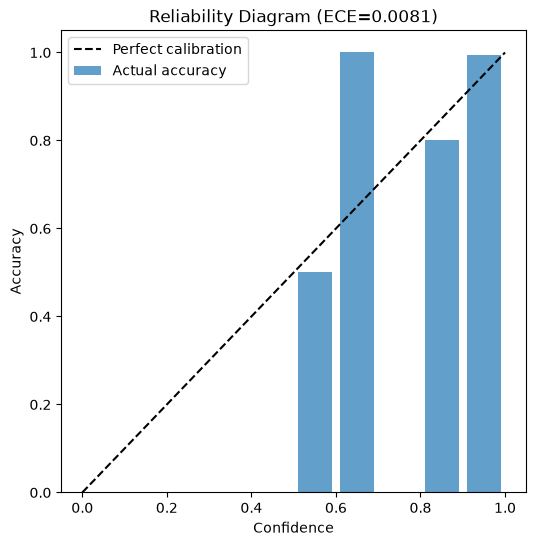

In [12]:
def compute_ece_and_reliability(confidences, correct, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    bin_accuracies = []
    bin_confidences = []
    bin_counts = []

    ece = 0.0
    for lower, upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > lower) & (confidences <= upper)
        n_in_bin = in_bin.sum()
        if n_in_bin > 0:
            bin_acc = correct[in_bin].mean()
            bin_conf = confidences[in_bin].mean()
            ece += (n_in_bin / len(confidences)) * abs(bin_acc - bin_conf)
        else:
            bin_acc = np.nan
            bin_conf = np.nan
        bin_accuracies.append(bin_acc)
        bin_confidences.append(bin_conf)
        bin_counts.append(n_in_bin)

    return ece, bin_lowers, bin_uppers, bin_accuracies, bin_confidences, bin_counts


ece_before, bin_lowers, bin_uppers, bin_accs, bin_confs, bin_counts = compute_ece_and_reliability(all_confidences, all_correct)

print("ECE (before calibration):", ece_before)
for lo, hi, acc, conf, count in zip(bin_lowers, bin_uppers, bin_accs, bin_confs, bin_counts):
    print(f"  [{lo:.1f}-{hi:.1f}]: n={count}, mean_confidence={conf}, actual_accuracy={acc}")

plt.figure(figsize=(6, 6))
bin_centers = (bin_lowers + bin_uppers) / 2
plt.bar(bin_centers, np.nan_to_num(bin_accs), width=0.08, alpha=0.7, label='Actual accuracy')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.legend()
plt.title(f'Reliability Diagram (ECE={ece_before:.4f})')
plt.show()

In [13]:
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for images_batch, labels_batch in loader:
            images_batch = images_batch.to(device)
            outputs = model(images_batch)
            all_logits.append(outputs['class_logits'].cpu())
            all_labels.append(labels_batch)
    return torch.cat(all_logits), torch.cat(all_labels)

val_dataset_mh = CurriculumLensDataset(images[val_idx], metadata_with_heads.iloc[val_idx])
val_loader_mh = DataLoader(val_dataset_mh, batch_size=32, shuffle=False)

val_logits, val_labels = get_logits_and_labels(eval_model, val_loader_mh, device)

temperature = nn.Parameter(torch.ones(1) * 1.5)
temp_optimizer = optim.LBFGS([temperature], lr=0.01, max_iter=50)

def temp_loss():
    temp_optimizer.zero_grad()
    scaled_logits = val_logits / temperature
    loss = nn.functional.cross_entropy(scaled_logits, val_labels)
    loss.backward()
    return loss

temp_optimizer.step(temp_loss)
print("Learned temperature:", temperature.item())

Learned temperature: 1.619252324104309


Mean confidence (after calibration): 0.9905581
Actual accuracy (unchanged, same predictions): 0.989983305509182

ECE (after calibration): 0.005128929332421105
  [0.0-0.1]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.1-0.2]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.2-0.3]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.3-0.4]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.4-0.5]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.5-0.6]: n=4, mean_confidence=0.5583639144897461, actual_accuracy=0.75
  [0.6-0.7]: n=0, mean_confidence=nan, actual_accuracy=nan
  [0.7-0.8]: n=5, mean_confidence=0.7646842002868652, actual_accuracy=0.8
  [0.8-0.9]: n=3, mean_confidence=0.8597168326377869, actual_accuracy=1.0
  [0.9-1.0]: n=587, mean_confidence=0.9960958361625671, actual_accuracy=0.9931856899488927


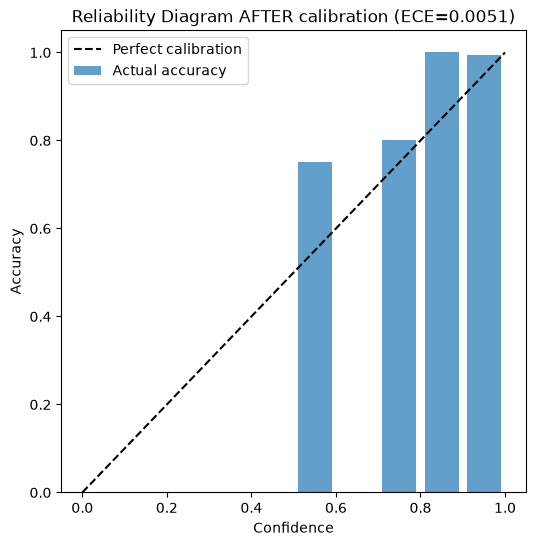

In [14]:
test_logits, test_labels_t = get_logits_and_labels(eval_model, test_loader_mh, device)

with torch.no_grad():
    scaled_test_logits = test_logits / temperature.item()
    scaled_probs = torch.softmax(scaled_test_logits, dim=1)
    scaled_confidences, scaled_predicted = torch.max(scaled_probs, dim=1)

scaled_confidences = scaled_confidences.numpy()
scaled_correct = (scaled_predicted.numpy() == test_labels_t.numpy())

print("Mean confidence (after calibration):", scaled_confidences.mean())
print("Actual accuracy (unchanged, same predictions):", scaled_correct.mean())

ece_after, bin_lowers_a, bin_uppers_a, bin_accs_a, bin_confs_a, bin_counts_a = compute_ece_and_reliability(scaled_confidences, scaled_correct)

print("\nECE (after calibration):", ece_after)
for lo, hi, acc, conf, count in zip(bin_lowers_a, bin_uppers_a, bin_accs_a, bin_confs_a, bin_counts_a):
    print(f"  [{lo:.1f}-{hi:.1f}]: n={count}, mean_confidence={conf}, actual_accuracy={acc}")

plt.figure(figsize=(6, 6))
bin_centers = (bin_lowers_a + bin_uppers_a) / 2
plt.bar(bin_centers, np.nan_to_num(bin_accs_a), width=0.08, alpha=0.7, label='Actual accuracy')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.legend()
plt.title(f'Reliability Diagram AFTER calibration (ECE={ece_after:.4f})')
plt.show()

In [15]:
def correct_for_prior_shift(p_lens, train_prior=0.5, real_world_prior=1/5000):
    numerator = p_lens * (real_world_prior / train_prior)
    denominator = numerator + (1 - p_lens) * ((1 - real_world_prior) / (1 - train_prior))
    return numerator / denominator

example_confidences = np.array([0.99, 0.95, 0.90, 0.999, 0.5435])
corrected = [correct_for_prior_shift(p) for p in example_confidences]

for original, corr in zip(example_confidences, corrected):
    print(f"Trained-domain confidence {original:.4f} -> real-world-corrected confidence {corr:.6f}")

Trained-domain confidence 0.9900 -> real-world-corrected confidence 0.019419
Trained-domain confidence 0.9500 -> real-world-corrected confidence 0.003786
Trained-domain confidence 0.9000 -> real-world-corrected confidence 0.001797
Trained-domain confidence 0.9990 -> real-world-corrected confidence 0.166556
Trained-domain confidence 0.5435 -> real-world-corrected confidence 0.000238


In [16]:
from astroquery.vizier import Vizier

Vizier.ROW_LIMIT = -1
catalog_list = Vizier.find_catalogs('SLACS')
print(catalog_list)

OrderedDict([('J/ApJ/682/964', </>), ('J/ApJ/690/670', </>)])


In [17]:
Vizier.ROW_LIMIT = 20
slacs_catalog = Vizier.get_catalogs('J/ApJ/682/964')
print(slacs_catalog)

TableList with 3 tables:
	'0:J/ApJ/682/964/table4' with 17 column(s) and 20 row(s) 
	'1:J/ApJ/682/964/notes' with 2 column(s) and 10 row(s) 
	'2:J/ApJ/682/964/table5' with 12 column(s) and 20 row(s) 


In [18]:
table4 = slacs_catalog['J/ApJ/682/964/table4']
print(table4.colnames)
print(table4[:5])

['SDSS', 'zFG', 'zBG', 'Imag', 'n_Imag', 'Name', 'L(V555)', 'Re', 'b/a', 'sigma', 'Mph', 'Mul', 'Lens', 'n_Lens', 'Sloan', '_RA', '_DE']
       SDSS          zFG     zBG    Imag ... n_Lens Sloan    _RA       _DE   
                                    mag  ...                 deg       deg   
------------------ ------- ------- ----- ... ------ ----- --------- ---------
000802.96-000408.2  0.4400  1.1924 18.65 ...        Sloan   2.01233  -0.06894
002817.87-092934.3  0.0565  0.7146 13.75 ...        Sloan   7.07446  -9.49286
002907.77-005550.5  0.2270  0.9313 17.09 ...        Sloan   7.28237  -0.93069
003753.21-094220.1  0.1955  0.6322 16.26 ...        Sloan   9.47171  -9.70558
004402.90+011312.6  0.1196  0.1965 15.73 ...        Sloan  11.01208   1.22017


In [19]:
Vizier.ROW_LIMIT = 20
slacs_full = Vizier.get_catalogs('J/ApJ/682/964')['J/ApJ/682/964/table4']
slacs_df = slacs_full.to_pandas()
print(slacs_df[['SDSS', '_RA', '_DE', 'Lens']].head(20))

                  SDSS        _RA       _DE Lens
0   000802.96-000408.2    2.01233  -0.06894    A
1   002817.87-092934.3    7.07446  -9.49286    X
2   002907.77-005550.5    7.28237  -0.93069    A
3   003753.21-094220.1    9.47171  -9.70558    A
4   004402.90+011312.6   11.01208   1.22017    A
5   010933.73+150032.5   17.39054  15.00903    A
6   015758.94-005626.1   29.49558  -0.94058    A
7   021652.54-081345.3   34.21892  -8.22925    A
8   025245.21+003958.4   43.18837   0.66622    A
9   033012.14-002051.9   52.55058  -0.34775    A
10  035458.47-064842.8   58.74362  -6.81189    X
11  040535.41-045552.4   61.39754  -4.93122    A
12  072804.95+383525.7  112.02062  38.59047    A
13  073728.45+321618.6  114.36854  32.27183    A
14  074251.84+345001.9  115.71600  34.83386    X
15  075834.68+303443.3  119.64450  30.57869    B
16  080240.82+450452.7  120.67008  45.08131    X
17  080358.21+453655.6  120.99254  45.61544    X
18  080858.78+470638.9  122.24492  47.11081    A
19  081931.93+453444

In [21]:
Vizier.ROW_LIMIT = 20
slacs_full = Vizier.get_catalogs('J/ApJ/682/964')['J/ApJ/682/964/table4']
slacs_df = slacs_full.to_pandas()
grade_a = slacs_df[slacs_df['Lens'] == 'A'].head(8)
print(len(grade_a))

8


In [22]:
import os
import json

results_path = '../data/processed/slacs_real_test_results.json'

if os.path.exists(results_path):
    with open(results_path) as f:
        real_lens_results_saved = json.load(f)
else:
    real_lens_results_saved = {}

for _, lens_row in grade_a.iterrows():
    sdss_name = lens_row['SDSS']

    if sdss_name in real_lens_results_saved:
        print(f"{sdss_name}: already processed (P(lens)={real_lens_results_saved[sdss_name]['prob_lens']:.4f}), skipping")
        continue

    try:
        coord = SkyCoord(ra=lens_row['_RA']*u.deg, dec=lens_row['_DE']*u.deg)
        obs = Observations.query_criteria(coordinates=coord, radius="10 arcsec", obs_collection="HST", instrument_name="ACS/WFC")
        if len(obs) == 0:
            print(f"{sdss_name}: no HST/ACS data found, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'no_data'}
            continue

        f814w_obs = [o for o in obs if 'F814W' in str(o['filters'])]
        if not f814w_obs:
            print(f"{sdss_name}: no F814W, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'no_f814w'}
            continue
        target_obs_id = f814w_obs[0]['obs_id']

        products = Observations.get_product_list(obs[obs['obs_id']==target_obs_id])
        drc_products = products[(products['productType']=='SCIENCE') & (products['productSubGroupDescription']=='DRC')]
        if len(drc_products) == 0:
            print(f"{sdss_name}: no DRC product, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'no_drc'}
            continue

        local_dir = f"../data/raw/slacs_{sdss_name}"
        expected_filename = drc_products['productFilename'][0]
        expected_path = os.path.join(local_dir, 'mastDownload', 'HST', target_obs_id, expected_filename)

        if os.path.exists(expected_path) and os.path.getsize(expected_path) > 1_000_000:
            print(f"{sdss_name}: file already on disk ({os.path.getsize(expected_path)/1e6:.1f} MB), skipping download")
            path = expected_path
        else:
            dl = Observations.download_products(drc_products[:1], download_dir=local_dir, cache=True)
            path = dl['Local Path'][0]

        with fits.open(path) as hdul_lens:
            sci = hdul_lens['SCI'].data
            wcs_lens = WCS(hdul_lens['SCI'].header)

        x_pix, y_pix = wcs_lens.world_to_pixel(coord)
        x_int, y_int = int(round(float(x_pix))), int(round(float(y_pix)))
        crop = sci[y_int-60:y_int+60, x_int-60:x_int+60]

        if crop.shape != (120, 120):
            print(f"{sdss_name}: crop out of bounds, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'bad_crop'}
            continue

        crop_norm = np.clip(crop, np.percentile(crop, 1), np.percentile(crop, 99.5))
        crop_norm = (crop_norm - crop_norm.min()) / (crop_norm.max() - crop_norm.min() + 1e-10)

        img_tensor = torch.from_numpy(crop_norm).float().unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            out = eval_model(img_tensor)
            prob_lens = torch.softmax(out['class_logits'], dim=1)[0,1].item()

        real_lens_results_saved[sdss_name] = {'prob_lens': prob_lens, 'status': 'ok'}
        print(f"{sdss_name}: P(lens)={prob_lens:.4f}")

    except Exception as e:
        print(f"{sdss_name}: ERROR - {e}")
        real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': f'error: {str(e)[:100]}'}

    with open(results_path, 'w') as f:
        json.dump(real_lens_results_saved, f, indent=2)

print(f"\nProcessed: {sum(1 for v in real_lens_results_saved.values() if v['status']=='ok')}/{len(grade_a)} real lenses successfully")

000802.96-000408.2: already processed (P(lens)=0.4305), skipping
002907.77-005550.5: already processed (P(lens)=0.9522), skipping
003753.21-094220.1: already processed (P(lens)=0.4202), skipping
004402.90+011312.6: ERROR - name 'SkyCoord' is not defined
010933.73+150032.5: ERROR - name 'SkyCoord' is not defined
015758.94-005626.1: ERROR - name 'SkyCoord' is not defined
021652.54-081345.3: ERROR - name 'SkyCoord' is not defined
025245.21+003958.4: ERROR - name 'SkyCoord' is not defined

Processed: 3/8 real lenses successfully


In [23]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.io import fits
from astroquery.mast import Observations

for name in list(real_lens_results_saved.keys()):
    if real_lens_results_saved[name]['status'].startswith('error'):
        del real_lens_results_saved[name]

with open(results_path, 'w') as f:
    json.dump(real_lens_results_saved, f, indent=2)

print("Cleared bad error entries, remaining:", list(real_lens_results_saved.keys()))

Cleared bad error entries, remaining: ['000802.96-000408.2', '002907.77-005550.5', '003753.21-094220.1']


In [24]:
for _, lens_row in grade_a.iterrows():
    sdss_name = lens_row['SDSS']

    if sdss_name in real_lens_results_saved:
        print(f"{sdss_name}: already processed (P(lens)={real_lens_results_saved[sdss_name]['prob_lens']:.4f}), skipping")
        continue

    try:
        coord = SkyCoord(ra=lens_row['_RA']*u.deg, dec=lens_row['_DE']*u.deg)
        obs = Observations.query_criteria(coordinates=coord, radius="10 arcsec", obs_collection="HST", instrument_name="ACS/WFC")
        if len(obs) == 0:
            print(f"{sdss_name}: no HST/ACS data found, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'no_data'}
            continue

        f814w_obs = [o for o in obs if 'F814W' in str(o['filters'])]
        if not f814w_obs:
            print(f"{sdss_name}: no F814W, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'no_f814w'}
            continue
        target_obs_id = f814w_obs[0]['obs_id']

        products = Observations.get_product_list(obs[obs['obs_id']==target_obs_id])
        drc_products = products[(products['productType']=='SCIENCE') & (products['productSubGroupDescription']=='DRC')]
        if len(drc_products) == 0:
            print(f"{sdss_name}: no DRC product, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'no_drc'}
            continue

        local_dir = f"../data/raw/slacs_{sdss_name}"
        expected_filename = drc_products['productFilename'][0]
        expected_path = os.path.join(local_dir, 'mastDownload', 'HST', target_obs_id, expected_filename)

        if os.path.exists(expected_path) and os.path.getsize(expected_path) > 1_000_000:
            print(f"{sdss_name}: file already on disk ({os.path.getsize(expected_path)/1e6:.1f} MB), skipping download")
            path = expected_path
        else:
            dl = Observations.download_products(drc_products[:1], download_dir=local_dir, cache=True)
            path = dl['Local Path'][0]

        with fits.open(path) as hdul_lens:
            sci = hdul_lens['SCI'].data
            wcs_lens = WCS(hdul_lens['SCI'].header)

        x_pix, y_pix = wcs_lens.world_to_pixel(coord)
        x_int, y_int = int(round(float(x_pix))), int(round(float(y_pix)))
        crop = sci[y_int-60:y_int+60, x_int-60:x_int+60]

        if crop.shape != (120, 120):
            print(f"{sdss_name}: crop out of bounds, skipping")
            real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': 'bad_crop'}
            continue

        crop_norm = np.clip(crop, np.percentile(crop, 1), np.percentile(crop, 99.5))
        crop_norm = (crop_norm - crop_norm.min()) / (crop_norm.max() - crop_norm.min() + 1e-10)

        img_tensor = torch.from_numpy(crop_norm).float().unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            out = eval_model(img_tensor)
            prob_lens = torch.softmax(out['class_logits'], dim=1)[0,1].item()

        real_lens_results_saved[sdss_name] = {'prob_lens': prob_lens, 'status': 'ok'}
        print(f"{sdss_name}: P(lens)={prob_lens:.4f}")

    except Exception as e:
        print(f"{sdss_name}: ERROR - {e}")
        real_lens_results_saved[sdss_name] = {'prob_lens': None, 'status': f'error: {str(e)[:100]}'}

    with open(results_path, 'w') as f:
        json.dump(real_lens_results_saved, f, indent=2)

print(f"\nProcessed: {sum(1 for v in real_lens_results_saved.values() if v['status']=='ok')}/{len(grade_a)} real lenses successfully")

000802.96-000408.2: already processed (P(lens)=0.4305), skipping
002907.77-005550.5: already processed (P(lens)=0.9522), skipping
003753.21-094220.1: already processed (P(lens)=0.4202), skipping
INFO: Found cached file ../data/raw/slacs_004402.90+011312.6/mastDownload/HST/hst_10587_47_acs_wfc_f814w_j9em47ay/hst_10587_47_acs_wfc_f814w_j9em47ay_drc.fits with expected size 374791680. [astroquery.query]
004402.90+011312.6: P(lens)=0.3818


010933.73+150032.5: P(lens)=0.5776
015758.94-005626.1: P(lens)=0.2881
021652.54-081345.3: P(lens)=0.9875
025245.21+003958.4: P(lens)=0.1382

Processed: 8/8 real lenses successfully
